In [1]:
# MOTORSPORTS PERFORMANCE ANALYTICS SUITE
#
# Author: Melinda Walls
#
# Features:
# - Telemetry Analysis
# - Driver Comparison
# - Sector Performance
# - Tire Degradation Modeling
# - Race Strategy Optimization
# - Monte Carlo Simulation
# - Machine Learning Lap Time Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# ============================================================
# LOAD DATA
# ============================================================

lap1 = pd.read_csv("data/lap1.csv")
lap2 = pd.read_csv("data/lap2.csv")
telemetry = pd.read_csv("data/telemetry.csv")

In [2]:
# ============================================================
# BASIC TELEMETRY ANALYSIS
# ============================================================

def telemetry_summary(df):

    print("\n===== TELEMETRY SUMMARY =====")

    print(f"Average Speed: {df['Speed'].mean():.2f}")
    print(f"Maximum Speed: {df['Speed'].max():.2f}")
    print(f"Minimum Speed: {df['Speed'].min():.2f}")

    if "Throttle" in df.columns:
        throttle_pct = (df["Throttle"] > 95).mean() * 100
        print(f"Full Throttle Time: {throttle_pct:.1f}%")

    if "Brake" in df.columns:
        brake_pct = (df["Brake"] > 5).mean() * 100
        print(f"Brake Usage: {brake_pct:.1f}%")


In [3]:
# ============================================================
# DRIVER COMPARISON
# ============================================================

def compare_laps(lap1, lap2):

    lap1_time = np.sum(1 / lap1["Speed"])
    lap2_time = np.sum(1 / lap2["Speed"])

    delta = lap2_time - lap1_time

    print("\n===== LAP COMPARISON =====")
    print(f"Lap Delta: {delta:.4f}")

    plt.figure(figsize=(10,5))

    plt.plot(
        lap1["Distance"],
        lap1["Speed"],
        label="Lap 1"
    )

    plt.plot(
        lap2["Distance"],
        lap2["Speed"],
        label="Lap 2"
    )

    plt.title("Speed Comparison")
    plt.xlabel("Distance")
    plt.ylabel("Speed")
    plt.legend()
    plt.grid()
    plt.show()

In [4]:
# ============================================================
# SECTOR ANALYSIS
# ============================================================

def sector_analysis(df):

    max_dist = df["Distance"].max()

    s1 = df[df["Distance"] <= max_dist/3]
    s2 = df[
        (df["Distance"] > max_dist/3) &
        (df["Distance"] <= 2*max_dist/3)
    ]
    s3 = df[df["Distance"] > 2*max_dist/3]

    print("\n===== SECTOR ANALYSIS =====")

    print(f"Sector 1 Avg Speed: {s1['Speed'].mean():.2f}")
    print(f"Sector 2 Avg Speed: {s2['Speed'].mean():.2f}")
    print(f"Sector 3 Avg Speed: {s3['Speed'].mean():.2f}")


In [5]:
# ============================================================
# TIRE DEGRADATION MODEL
# ============================================================

def tire_model():

    laps = np.arange(1,51)

    base_lap = 90.0
    fuel_burnoff = 0.04
    tire_deg = 0.06

    lap_times = (
        base_lap
        - fuel_burnoff * laps
        + tire_deg * laps**1.3
    )

    plt.figure(figsize=(10,5))

    plt.plot(laps, lap_times)

    plt.title("Tire Degradation Model")
    plt.xlabel("Lap")
    plt.ylabel("Lap Time")

    plt.grid()

    plt.show()


In [6]:
# ============================================================
# RACE STRATEGY OPTIMIZER
# ============================================================

def strategy_time(stints):

    pit_loss = 25

    total = 0

    for stint in stints:

        for lap in range(stint):

            total += (
                90
                + 0.05 * lap
            )

    total += pit_loss * (len(stints)-1)

    return total


def strategy_optimizer():

    strategies = {
        "1 Stop": [50,50],
        "2 Stop": [34,33,33],
        "3 Stop": [25,25,25,25]
    }

    print("\n===== STRATEGY RESULTS =====")

    for name, stints in strategies.items():

        total = strategy_time(stints)

        print(name, round(total,2))

In [7]:
# ============================================================
# MONTE CARLO SIMULATION
# ============================================================

def monte_carlo():

    sims = 10000

    results = []

    for _ in range(sims):

        cautions = np.random.poisson(2)

        race_time = np.random.normal(
            5400 + cautions*15,
            30
        )

        results.append(race_time)

    print("\n===== MONTE CARLO =====")
    print("Expected Race Time:",
          np.mean(results))


In [8]:
# ============================================================
# MACHINE LEARNING
# ============================================================

def lap_time_prediction(df):

    required = [
        "Speed",
        "Throttle",
        "Brake",
        "LapTime"
    ]

    if not all(col in df.columns for col in required):

        print(
            "\nMachine learning skipped "
            "(missing columns)"
        )

        return

    X = df[
        [
            "Speed",
            "Throttle",
            "Brake"
        ]
    ]

    y = df["LapTime"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=200
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_test)

    error = mean_absolute_error(
        y_test,
        predictions
    )

    print("\n===== ML MODEL =====")
    print(f"MAE: {error:.4f}")

In [9]:
# ============================================================
# TRACK MAP
# ============================================================

def track_map(df):

    if "X" not in df.columns:
        return

    if "Y" not in df.columns:
        return

    plt.figure(figsize=(8,8))

    scatter = plt.scatter(
        df["X"],
        df["Y"],
        c=df["Speed"]
    )

    plt.colorbar(scatter)

    plt.title("Track Map")

    plt.show()


===== TELEMETRY SUMMARY =====
Average Speed: 149.00
Maximum Speed: 180.00
Minimum Speed: 120.00
Full Throttle Time: 40.0%
Brake Usage: 20.0%

===== LAP COMPARISON =====
Lap Delta: 0.0002


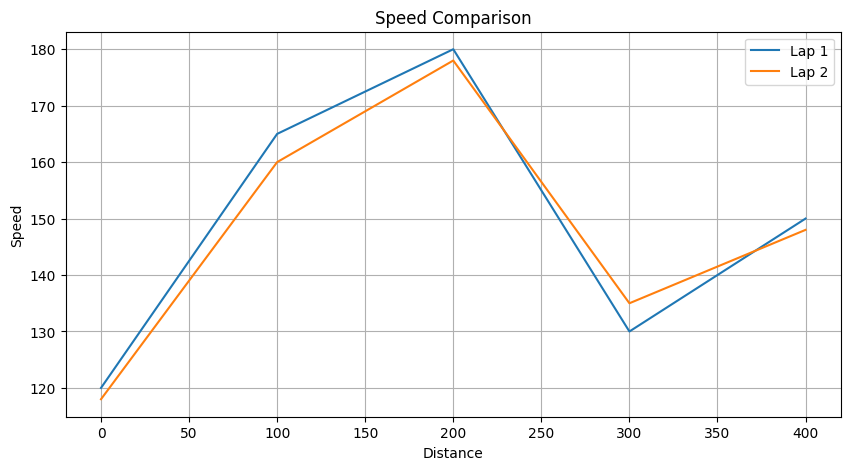


===== SECTOR ANALYSIS =====
Sector 1 Avg Speed: 142.50
Sector 2 Avg Speed: 180.00
Sector 3 Avg Speed: 140.00


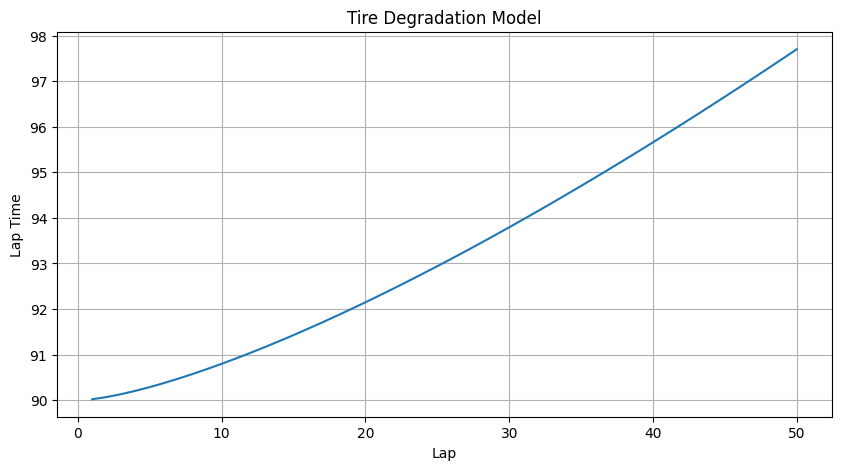


===== STRATEGY RESULTS =====
1 Stop 9147.5
2 Stop 9130.85
3 Stop 9135.0

===== MONTE CARLO =====
Expected Race Time: 5429.957036848728

Machine learning skipped (missing columns)


In [10]:
# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    telemetry_summary(telemetry)

    compare_laps(
        lap1,
        lap2
    )

    sector_analysis(telemetry)

    tire_model()

    strategy_optimizer()

    monte_carlo()

    lap_time_prediction(telemetry)

    track_map(telemetry)